# Part 4f — Interdiction, and what is worth defending

### Three levels, and the middle one needs duality

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sear-labs/advopt-lithiumsc/blob/main/notebooks/04f_interdiction.ipynb)

Every other notebook in this series asks *what should be built*. This one asks
something different: the chain already exists, so **what breaks it, and what is
worth protecting?**

That is a three-level problem, and the levels run inside-out:

| level | who | does what |
|---|---|---|
| innermost | **operator** | pushes as much material as the surviving network allows |
| middle | **attacker** | cuts `B` arcs to make that as small as possible |
| outermost | **defender** | fortifies `D` arcs, before the attacker moves |

### The obstacle, and the trick

The attacker wants to **minimise a maximum**. You cannot write that as one MILP —
the inner problem is a maximisation and it sits inside the objective.

Duality dissolves it. By max-flow/min-cut, the operator's optimum *equals* the
minimum cut, and a minimum cut is already a **minimisation**. So the attacker
minimises over cuts and interdiction decisions at the same time, in one model.
Section 4 builds it, and section 5 checks it against the operator's own LP at
every budget — because a dual formulation that is subtly wrong still returns
plausible numbers.

### Why the network is small, and why two arcs are sacred

Fourteen nodes. It has to be small enough that the middle level can be solved
*exactly*, so that the outer level has something trustworthy to optimise against.

The super-source and super-sink stand for a reserve base and an aggregate of
demand. **They are deliberately not attackable.** Nobody can sever "the concept
of demand"; leave them in and the attacker cuts the three source arcs, the
throughput goes to nothing, and the problem is over before it starts.

### The result worth staying for

Section 11 shows a sensible-looking shortcut **failing**. Restricting the
defender's candidates to arcs the attacker has already been seen to pick is the
obvious way to make enumeration affordable — and it costs 5.0 units of
throughput, because fortifying an arc changes which arcs are worth attacking.

## 0. Setup

One cell, and it is the only place the `lithium` package appears before the final check. On Colab it
clones the repo and installs it; locally it assumes you have already run `pip install -e .` and just
moves up out of `notebooks/` so the relative data paths work.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sear-labs/advopt-lithiumsc.git"
# Forked or renamed? Change BOTH halves of that path. Only the owner ever
# looked like a placeholder, and the repo name beside it broke 64 URLs once.
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")

if "google.colab" in sys.modules:
    if not Path(REPO_NAME).exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_NAME)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
elif Path.cwd().name == "notebooks":
    os.chdir("..")

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"font.size": 12, "axes.grid": True, "grid.alpha": 0.3})
print(f"working directory : {Path.cwd().name}")
print(f"gurobipy          : {gp.gurobi.version()}")
print(f"pandas            : {pd.__version__}")

working directory : Advanced Opt Modeling Examples
gurobipy          : (13, 0, 2)
pandas            : 2.3.3


## 2. The instance

One table: three regions, each with a reserve endowment and a delivery capacity.
Everything else about the network is derived from it, or is a knob.

**This is a fifth instance and it shares nothing with the others.** It is a flow
network, not a capacity-expansion model — there are no vintages, no periods, no
money. The only quantity is throughput.

In [2]:
DATA = Path("data/raw")

if not (DATA / "interdiction_regions.csv").exists():
    print("!" * 78)
    print("! data/raw/ was not found, so this notebook is FALLING BACK to generated")
    print("! numbers. Everything below will run, but the results are NOT the shipped")
    print("! instance and are NOT an acceptable submission.")
    print("! Fix: clone the repo (see section 0) or run from the repo root.")
    print("!" * 78)
    DATA = Path("_generated_fallback")
    DATA.mkdir(exist_ok=True)
    (DATA / "interdiction_regions.csv").write_text(
        "region,reserve_cap,delivery_cap\nCHN,55,45\nALY,18,40\nROW,70,35\n")

regions_df = pd.read_csv(DATA / "interdiction_regions.csv")
print(f"interdiction_regions.csv: {len(regions_df)} rows x "
      f"{len(regions_df.columns)} columns")
regions_df

interdiction_regions.csv: 3 rows x 3 columns


,region,reserve_cap,delivery_cap
0,CHN,55,45
1,ALY,18,40
2,ROW,70,35


Now the knobs, and the network built from them. `STAGES` is the chain; `CAP_INTRA`
and `CAP_INTER` are what make geography matter.

**The ratio between those two is the whole story of the network.** Set them equal
and every region becomes interchangeable, the attacker has no leverage, and the
defender has nothing to protect.

In [3]:
REGIONS = tuple(regions_df["region"])
RESERVE = dict(zip(regions_df["region"], regions_df["reserve_cap"].astype(float)))
DELIVER = dict(zip(regions_df["region"], regions_df["delivery_cap"].astype(float)))

STAGES = ("MINE", "REF", "CAM", "CELL")   # the chain
CAP_INTRA = 40.0    # staying inside a region is generous
CAP_INTER = 16.0    # crossing is thinner - this ratio is why geography matters


# THE FUNCTION IS THE LESSON: the node naming scheme is a modelling decision,
# not a formatting detail - every node in this network is a (stage, region)
# pair, and writing it once here is what keeps that visible in the arc lists.
def node(stage, region):
    return f"{stage}:{region}"


NODES = ["SRC"] + [node(s, r) for s in STAGES for r in REGIONS] + ["SNK"]

CAP = {}
for r in REGIONS:                                  # reserves feed the first stage
    CAP["SRC", node(STAGES[0], r)] = RESERVE[r]
for a, b in zip(STAGES, STAGES[1:]):               # stage to stage, all region pairs
    for r1 in REGIONS:
        for r2 in REGIONS:
            CAP[node(a, r1), node(b, r2)] = CAP_INTRA if r1 == r2 else CAP_INTER
for r in REGIONS:                                  # last stage delivers to demand
    CAP[node(STAGES[-1], r), "SNK"] = DELIVER[r]
ARCS = list(CAP)

# The super-source and super-sink are modelling artifacts - a reserve base and a
# demand aggregate, not physical links anyone can sever. Only stage-to-stage
# arcs are real connections, so only those are interdictable.
ATTACKABLE = [a for a in ARCS if a[0] != "SRC" and a[1] != "SNK"]

print(f"{len(NODES)} nodes, {len(ARCS)} arcs, {len(ATTACKABLE)} interdictable")
print(f"  {len(ARCS) - len(ATTACKABLE)} arcs are off limits: "
      f"{len(REGIONS)} source + {len(REGIONS)} sink")
print(f"\ncrossing a region costs {CAP_INTRA / CAP_INTER:.1f}x the capacity of "
      f"staying home")

14 nodes, 33 arcs, 27 interdictable
  6 arcs are off limits: 3 source + 3 sink

crossing a region costs 2.5x the capacity of staying home


## 3. The operator's problem

A plain max-flow LP: conservation at every interior node, capacity on every arc,
maximise what leaves the source. Interdicted arcs get an upper bound of zero.

**No binaries anywhere.** That is not incidental — it is what makes the duality
argument in section 4 available at all.

> **Predict before you run.** Reserves total 143 and delivery capacity totals
> 120. Which one binds?

In [4]:
import gurobipy as gp
from gurobipy import GRB
import itertools
import time


# THE FUNCTION IS THE LESSON: this is the innermost level, called from every
# section below - to check the attacker's dual, to score a fortification, and
# to bound the master. It is nine lines and each one is narrated above.
def max_flow(interdicted=frozenset()):
    """The operator: push as much as the surviving network allows."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    f = {a: m.addVar(lb=0.0, ub=(0.0 if a in interdicted else CAP[a])) for a in ARCS}
    for v in NODES:
        if v in ("SRC", "SNK"):
            continue
        m.addConstr(gp.quicksum(f[a] for a in ARCS if a[1] == v)
                    == gp.quicksum(f[a] for a in ARCS if a[0] == v), name=f"bal_{v}")
    m.setObjective(gp.quicksum(f[a] for a in ARCS if a[0] == "SRC"), GRB.MAXIMIZE)
    m.optimize()
    assert m.Status == GRB.OPTIMAL, f"max-flow not optimal (status {m.Status})"
    return m.ObjVal, {a: f[a].X for a in ARCS}


BASE_FLOW, flow0 = max_flow()
print(f"undisrupted throughput: {BASE_FLOW:.1f}")
print(f"  total reserves        {sum(RESERVE.values()):.0f}")
print(f"  total delivery capacity {sum(DELIVER.values()):.0f}")
print(f"\ndelivery is the binding side, so the chain is demand-limited, not "
      f"reserve-limited - which is why the attacker goes for the middle.")

Set parameter Username


Set parameter LicenseID to value 2750151


Academic license - for non-commercial use only - expires 2026-12-04


undisrupted throughput: 120.0
  total reserves        143
  total delivery capacity 120

delivery is the binding side, so the chain is demand-limited, not reserve-limited - which is why the attacker goes for the middle.


## 4. The attacker, as a single MILP

Here is the move. The attacker wants

$$\min_{\text{cuts } z} \; \Big[ \max_{\text{flow}} \text{throughput} \Big]$$

and that inner maximisation cannot live inside a MILP objective. But max-flow
equals min-cut, so replace the inner problem by its dual and the whole thing
becomes one minimisation:

- $\pi_v$ — a potential on each node. $\pi_{\text{SRC}} - \pi_{\text{SNK}} \ge 1$
  forces a genuine separation of source from sink.
- $\gamma_a \ge \pi_{a_0} - \pi_{a_1}$ — arc $a$ is in the cut.
- $\zeta_a$ — binary, the attack decision.
- $\omega_a \ge \gamma_a - \zeta_a$ — **the linearisation**, and the line to
  stare at. An arc that has been interdicted is already gone, so it costs nothing
  to include in the cut. Without this the attacker pays twice for its own attack.

The objective $\sum_a u_a \omega_a$ is the capacity of the cut the attacker has
to pay for.

In [5]:
# THE FUNCTION IS THE LESSON: this is the model the notebook is about, and
# sections 5 to 11 call it several thousand times at different budgets and
# fortifications. Every constraint is narrated directly above.
def attacker_best_response(budget, fortified=frozenset()):
    """Cut `budget` arcs to minimise the operator's throughput - exactly."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    pi = m.addVars(NODES, lb=0.0, name="pi")
    gam = m.addVars(ARCS, lb=0.0, name="gamma")
    om = m.addVars(ARCS, lb=0.0, name="omega")
    zet = m.addVars(ARCS, vtype=GRB.BINARY, name="zeta")

    m.addConstrs((gam[a] - pi[a[0]] + pi[a[1]] >= 0 for a in ARCS), name="cut")
    m.addConstr(pi["SRC"] - pi["SNK"] >= 1, name="sep")
    m.addConstrs((om[a] >= gam[a] - zet[a] for a in ARCS), name="lin")
    m.addConstr(gp.quicksum(zet[a] for a in ATTACKABLE) <= budget, name="budget")
    for a in ARCS:
        if a not in set(ATTACKABLE) or a in fortified:
            m.addConstr(zet[a] == 0)

    m.setObjective(gp.quicksum(CAP[a] * om[a] for a in ARCS), GRB.MINIMIZE)
    m.optimize()
    assert m.SolCount > 0, f"the attacker MILP found no solution ({m.Status})"
    return m.ObjVal, frozenset(a for a in ARCS if zet[a].X > 0.5)

## 5. Verify the dual — do not take it on faith

A wrong dual formulation does not crash. It returns numbers, and they look like
throughput. The only way to know it is right is to take the attack it proposes,
hand it to the **operator's own LP**, and check the two agree.

This is the single most important cell in the notebook. If it fails, everything
downstream is confidently wrong.

In [6]:
rows = []
for B in range(0, 7):
    milp_val, attack = attacker_best_response(B)
    direct, _ = max_flow(interdicted=attack)      # the operator, under that attack
    rows.append(dict(budget=B, milp_value=round(milp_val, 2),
                     direct_max_flow=round(direct, 2),
                     agree=abs(milp_val - direct) < 1e-6,
                     attack=", ".join(sorted(f"{a[0]}->{a[1]}" for a in attack)) or "(none)"))
    assert abs(milp_val - direct) < 1e-6, (
        f"budget {B}: the min-cut MILP says {milp_val:.4f} but the operator's "
        f"own LP achieves {direct:.4f} under that exact attack - the dual is wrong")
verify = pd.DataFrame(rows)
assert verify.agree.all()
print("the min-cut MILP reproduces the operator's max-flow at every budget")
verify[["budget", "milp_value", "direct_max_flow", "attack"]]

the min-cut MILP reproduces the operator's max-flow at every budget


,budget,milp_value,direct_max_flow,attack
0,0,120.0,120.0,(none)
1,1,105.0,105.0,MINE:ROW->REF:ROW
2,2,82.0,82.0,"MINE:CHN->REF:CHN, MINE:ROW->REF:ROW"
3,3,66.0,66.0,"MINE:CHN->REF:CHN, MINE:CHN->REF:ROW, MINE:ROW..."
4,4,50.0,50.0,"MINE:CHN->REF:ALY, MINE:CHN->REF:CHN, MINE:CHN..."
5,5,34.0,34.0,"MINE:CHN->REF:ALY, MINE:CHN->REF:CHN, MINE:CHN..."
6,6,18.0,18.0,"MINE:CHN->REF:ALY, MINE:CHN->REF:CHN, MINE:CHN..."


Exact at every budget. Note what the attacker chooses: **it goes for the mining
tier every time**, never the later stages. Reserves feed the whole chain through
a small number of fat arcs, so cutting there is worth more per unit of budget
than cutting anywhere downstream.

The damage is also close to linear — roughly 15 to 16 units of throughput per
arc cut — right up to the point where there is nothing left.

marginal damage per arc: [np.float64(15.0), np.float64(23.0), np.float64(16.0), np.float64(16.0), np.float64(16.0), np.float64(16.0)]


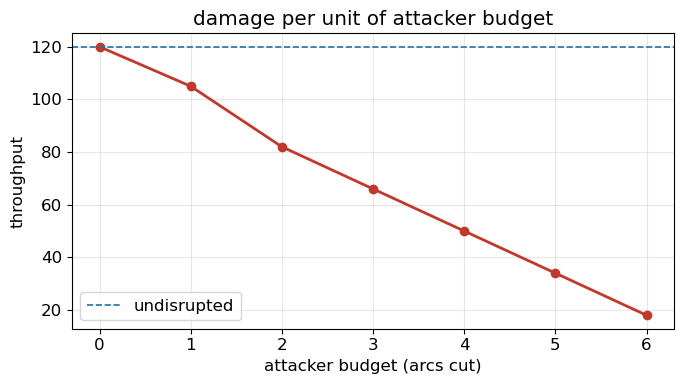

,budget,throughput,loss,loss_pct
0,0,120.0,0.0,0.0
1,1,105.0,15.0,12.5
2,2,82.0,38.0,31.7
3,3,66.0,54.0,45.0
4,4,50.0,70.0,58.3
5,5,34.0,86.0,71.7
6,6,18.0,102.0,85.0


In [7]:
dmg = pd.DataFrame([dict(budget=r.budget, throughput=r.milp_value,
                         loss=round(BASE_FLOW - r.milp_value, 1),
                         loss_pct=round(100 * (BASE_FLOW - r.milp_value) / BASE_FLOW, 1))
                    for r in verify.itertuples()])
assert dmg.throughput.is_monotonic_decreasing, \
    "throughput rose with a larger attacker budget, which is impossible"
print(f"marginal damage per arc: "
      f"{[round(dmg.throughput[i] - dmg.throughput[i+1], 1) for i in range(len(dmg)-1)]}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dmg.budget, dmg.throughput, "o-", color="#c0392b", lw=2)
ax.axhline(BASE_FLOW, color="#2471a3", ls="--", lw=1.2, label="undisrupted")
ax.set_xlabel("attacker budget (arcs cut)")
ax.set_ylabel("throughput")
ax.set_title("damage per unit of attacker budget")
ax.legend()
fig.tight_layout()
plt.show()
dmg

## 6. The defender, by enumeration

Fortify `D` arcs first; the attacker then plays its best response against what
is left. Enumerating every combination is the honest way to start, because it
cannot be wrong — it is just expensive.

**The default candidate set is the full interdictable set**, all 27 arcs.
Section 11 is about what happens when you shrink it.

> **Predict before you run.** With a defence budget of 1 against an attacker
> budget of 3, roughly how much of the 54 lost units do you expect to recover?

In [8]:
# THE FUNCTION IS THE LESSON: the outer level, and section 11 calls it with two
# different candidate sets in order to show one of them failing.
def defender(bdef, batk, candidates=None, verbose=True):
    """Fortify `bdef` arcs by brute force. `candidates=None` means ALL of them."""
    cands = sorted(ATTACKABLE) if candidates is None else sorted(candidates)
    n_combos = len(list(itertools.combinations(cands, bdef)))
    best = (-1.0, None, None)
    for combo in itertools.combinations(cands, bdef):
        val, atk = attacker_best_response(batk, fortified=frozenset(combo))
        if val > best[0]:
            best = (val, combo, atk)
    if verbose:
        print(f"  {len(cands)} candidate arcs -> {n_combos} fortification sets, "
              f"each needing one attacker MILP")
    return best


BATK = 3
no_def, atk0 = attacker_best_response(BATK)
print(f"attacker budget {BATK}, no defence -> throughput {no_def:.2f} "
      f"(loses {BASE_FLOW - no_def:.1f}, or {100 * (BASE_FLOW - no_def) / BASE_FLOW:.1f}%)\n")

defence = {}
for bdef in (1, 2):
    t0 = time.time()
    val, fort, atk = defender(bdef, BATK)
    defence[bdef] = (val, fort, atk)
    print(f"defend {bdef}: throughput {val:.2f}  "
          f"recovers {val - no_def:.2f} of the {BASE_FLOW - no_def:.2f} lost "
          f"({time.time() - t0:.1f}s)")
    print(f"  fortify: {', '.join(f'{a[0]}->{a[1]}' for a in fort)}")
    print(f"  attacker then hits: "
          f"{', '.join(sorted(f'{a[0]}->{a[1]}' for a in atk))}\n")

assert defence[2][0] >= defence[1][0], "a larger defence budget did worse"

attacker budget 3, no defence -> throughput 66.00 (loses 54.0, or 45.0%)



  27 candidate arcs -> 27 fortification sets, each needing one attacker MILP
defend 1: throughput 75.00  recovers 9.00 of the 54.00 lost (0.1s)
  fortify: MINE:ROW->REF:ROW
  attacker then hits: CAM:ALY->CELL:CHN, CAM:CHN->CELL:CHN, CAM:ROW->CELL:CHN



  27 candidate arcs -> 351 fortification sets, each needing one attacker MILP
defend 2: throughput 80.00  recovers 14.00 of the 54.00 lost (1.3s)
  fortify: CAM:ALY->CELL:CHN, MINE:ROW->REF:ROW
  attacker then hits: CAM:ALY->CELL:ALY, CAM:CHN->CELL:ALY, CAM:ROW->CELL:ALY



**Defence is worth much less than attack.** One arc of defence recovers 9 of the
54 units lost; a second recovers 5 more. The attacker spends 3 arcs to destroy 54
units; the defender spends 2 to restore 14.

That asymmetry is structural, not an artefact of these numbers: the attacker
picks *after* seeing the fortification, so it always redirects to whatever is
now cheapest. Defence buys a floor, not a repair.

Notice the attacker's response changes completely once MINE:ROW→REF:ROW is
protected — it abandons the mining tier and goes after CAM→CELL instead. **Hold
on to that**, because it is exactly why section 11's shortcut fails.

In [9]:
from collections import Counter

seen = Counter()
for B in range(1, 7):
    _, atk = attacker_best_response(B)
    seen.update(atk)
crit = pd.DataFrame([dict(arc=f"{a[0]} -> {a[1]}", capacity=CAP[a], times_chosen=n)
                     for a, n in seen.most_common()])
print(f"{len(crit)} distinct arcs are chosen across budgets 1-6, "
      f"out of {len(ATTACKABLE)} interdictable")
crit

6 distinct arcs are chosen across budgets 1-6, out of 27 interdictable


,arc,capacity,times_chosen
0,MINE:ROW -> REF:ROW,40.0,6
1,MINE:CHN -> REF:CHN,40.0,5
2,MINE:CHN -> REF:ROW,16.0,4
3,MINE:CHN -> REF:ALY,16.0,3
4,MINE:ROW -> REF:ALY,16.0,2
5,MINE:ROW -> REF:CHN,16.0,1


Only **six** arcs are ever chosen, and every one of them is in the mining tier.
That is a tempting observation, and section 11 is about why acting on it is a
mistake.

## 7. Best Response Intersection — replacing enumeration

Enumeration is $\binom{27}{D}$ attacker MILPs. At $D = 2$ that is 351; at
$D = 4$ it is 17,550. The method that replaces it is the same shape as Part 2b's
L-shaped decomposition, and it has the same virtue: **a bound, not a hope.**

Keep a set of attacks. Then repeat:

1. **Master** — fortify to maximise the worst throughput *over the attacks seen
   so far*. It only defends against what it has been shown, so it is a
   relaxation and its value is a valid **upper bound**.
2. **Subproblem** — let the attacker respond to that fortification. That
   fortification is real and this is its true value, so it is a valid **lower
   bound**.
3. Add the new attack to the set and repeat.

Stop when the bounds meet, or when the attacker repeats an attack already in the
set — at which point no new information can arrive.

In [10]:
# THE FUNCTION IS THE LESSON: the master is an iterative construction whose
# whole content is which attacks it has been shown so far.
def defender_master(attacks, bdef, ub_theta):
    """Fortify to maximise the worst flow over a RETAINED set of attacks."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    phi = m.addVars(ATTACKABLE, vtype=GRB.BINARY, name="phi")
    th = m.addVar(lb=0.0, ub=ub_theta, name="theta")
    m.addConstr(gp.quicksum(phi[a] for a in ATTACKABLE) <= bdef, name="budget")

    for j, atk in enumerate(attacks):
        f = m.addVars(ARCS, lb=0.0, name=f"f{j}")
        for a in ARCS:
            # an attacked arc survives only where it was fortified
            m.addConstr(f[a] <= (CAP[a] * phi[a] if a in atk else CAP[a]))
        for v in NODES:
            if v in ("SRC", "SNK"):
                continue
            m.addConstr(gp.quicksum(f[a] for a in ARCS if a[1] == v)
                        == gp.quicksum(f[a] for a in ARCS if a[0] == v))
        m.addConstr(th <= gp.quicksum(f[a] for a in ARCS if a[0] == "SRC"))

    m.setObjective(th, GRB.MAXIMIZE)
    m.optimize()
    assert m.SolCount > 0, "the defender master found no solution"
    return m.ObjVal, frozenset(a for a in ATTACKABLE if phi[a].X > 0.5)


def bri(bdef, batk, max_iter=40, tol=1e-6, verbose=True):
    """Alternate master and attacker until the bounds meet."""
    v0, a0 = attacker_best_response(batk)
    attacks, lb, best_fort, hist = [a0], v0, frozenset(), []
    for it in range(1, max_iter + 1):
        ub, fort = defender_master(attacks, bdef, ub_theta=BASE_FLOW)
        val, atk = attacker_best_response(batk, fortified=fort)
        if val > lb:
            lb, best_fort = val, fort
        hist.append(dict(iter=it, UB=round(ub, 4), LB=round(lb, 4),
                         gap=round(ub - lb, 6), attacks=len(attacks)))
        if verbose:
            print(f"  it {it:2d}  UB {ub:8.3f}  LB {lb:8.3f}  gap {ub - lb:8.5f}  "
                  f"|J|={len(attacks)}")
        if ub - lb < tol or atk in attacks:
            break
        attacks.append(atk)
    return lb, best_fort, pd.DataFrame(hist)


print(f"BRI, defend 1 against attacker budget {BATK}:")
bri_val, bri_fort, bri_hist = bri(1, BATK)
print(f"\nvalue {bri_val:.2f}  fortify: "
      f"{', '.join(f'{a[0]}->{a[1]}' for a in bri_fort)}")

BRI, defend 1 against attacker budget 3:
  it  1  UB  105.000  LB   73.000  gap 32.00000  |J|=1
  it  2  UB  104.000  LB   75.000  gap 29.00000  |J|=2
  it  3  UB   75.000  LB   75.000  gap  0.00000  |J|=3

value 75.00  fortify: MINE:ROW->REF:ROW


## 8. It must reproduce the enumerated optimum

Three iterations against 351 attacker solves. The bounds must bracket the truth
throughout, and the final value must equal what enumeration found.

**Assert the value, not the fortification.** Where two fortifications are equally
good the method may return either, and asserting on which one it picked would be
asserting on a tie — exactly the trap the series has hit before.

In [11]:
rows = []
for bdef in (1, 2):
    enum_val, enum_fort, _ = defence[bdef]
    b_val, b_fort, b_hist = bri(bdef, BATK, verbose=False)
    rows.append(dict(defence_budget=bdef,
                     enumeration=round(enum_val, 3), BRI=round(b_val, 3),
                     bri_iterations=len(b_hist),
                     enum_solves=len(list(itertools.combinations(sorted(ATTACKABLE), bdef))),
                     same_fortification=(set(enum_fort) == set(b_fort))))
    assert abs(enum_val - b_val) < 1e-6, (
        f"defend {bdef}: BRI got {b_val:.4f}, enumeration {enum_val:.4f}")
    assert (b_hist.UB >= b_hist.LB - 1e-9).all(), \
        "an upper bound fell below a lower bound"
cmpt = pd.DataFrame(rows)
print("BRI reproduces the enumerated optimum at both defence budgets")
print("(the fortification sets may differ where two are equally good - the")
print(" VALUE is what must match, and it is what the assertion checks)")
cmpt

BRI reproduces the enumerated optimum at both defence budgets
(the fortification sets may differ where two are equally good - the
 VALUE is what must match, and it is what the assertion checks)


,defence_budget,enumeration,BRI,bri_iterations,enum_solves,same_fortification
0,1,75.0,75.0,3,27,True
1,2,80.0,80.0,4,351,False


The bounds, drawn. The upper bound falls as the master is shown attacks it
cannot defend against; the lower bound rises as better fortifications are found.

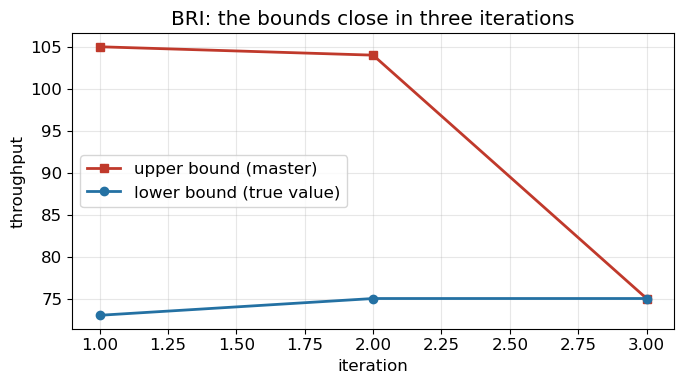

,iter,UB,LB,gap,attacks
0,1,105.0,73.0,32.0,1
1,2,104.0,75.0,29.0,2
2,3,75.0,75.0,0.0,3


In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bri_hist["iter"], bri_hist.UB, "s-", color="#c0392b", lw=2,
        label="upper bound (master)")
ax.plot(bri_hist["iter"], bri_hist.LB, "o-", color="#2471a3", lw=2,
        label="lower bound (true value)")
ax.set_xlabel("iteration")
ax.set_ylabel("throughput")
ax.set_title("BRI: the bounds close in three iterations")
ax.legend()
fig.tight_layout()
plt.show()
bri_hist

## 9. The candidate-restriction trap

Section 6 found that only a handful of arcs are ever attacked. The obvious
economy is to let the defender consider only those, and the cell below counts
exactly how much cheaper that makes the enumeration.

It is wrong, and this is the cell that proves it.

> **Predict before you run.** The attacker only ever picks from that handful of
> arcs. So defending only those should lose nothing. Should it?

In [13]:
seen_arcs = set()
for B in range(1, BATK + 3):
    _, atk = attacker_best_response(B)
    seen_arcs |= set(atk)
restricted = sorted(seen_arcs)
print(f"full interdictable set: {len(ATTACKABLE)} arcs | "
      f"restricted set: {len(restricted)} arcs\n")

rows = []
for bdef in (1, 2):
    full_v, full_f, _ = defence[bdef]
    rest_v, rest_f, _ = defender(bdef, BATK, candidates=restricted, verbose=False)
    rows.append(dict(defence_budget=bdef, full_set=round(full_v, 3),
                     restricted_set=round(rest_v, 3),
                     throughput_lost=round(full_v - rest_v, 3),
                     combos_full=len(list(itertools.combinations(sorted(ATTACKABLE), bdef))),
                     combos_restricted=len(list(itertools.combinations(restricted, bdef)))))
trap = pd.DataFrame(rows)

assert (trap.restricted_set <= trap.full_set + 1e-9).all(), \
    "the restricted set beat the full set, which is impossible"
assert trap.throughput_lost.max() > 1e-6, (
    "the restriction cost nothing on this instance, so section 9's whole point "
    "has gone - the prose would need rewriting, not the assertion relaxing")
worst = trap.loc[trap.throughput_lost.idxmax()]
print(f"at defence budget {worst.defence_budget:.0f} the restricted set gives "
      f"{worst.restricted_set:.2f} against {worst.full_set:.2f} - "
      f"it loses {worst.throughput_lost:.2f} units of throughput")
trap

full interdictable set: 27 arcs | restricted set: 5 arcs



at defence budget 2 the restricted set gives 75.00 against 80.00 - it loses 5.00 units of throughput


,defence_budget,full_set,restricted_set,throughput_lost,combos_full,combos_restricted
0,1,75.0,75.0,0.0,27,5
1,2,80.0,75.0,5.0,351,10


**It loses 5.0 units, and the assertion above requires that it does.**

The reasoning behind the shortcut was: *the attacker only ever picks these six
arcs, so those are the only ones worth protecting.* The flaw is in the tense.
Those are the arcs the attacker picks **when nothing is fortified**. Fortify one,
and the attacker's calculus changes — section 6 already showed it abandoning the
mining tier once MINE:ROW→REF:ROW was protected.

The best second arc to fortify is `CAM:ALY→CELL:CHN`, which **no unfortified
attacker ever touches**. It is not worth attacking until the mining tier is
already defended, and by then the candidate set has excluded it.

**The general form of this mistake:** you cannot narrow a defender's options
using observations made in a world where the defender did nothing. It shows up
whenever a heuristic is calibrated on the status quo and then applied to a
changed one, and it never announces itself — the restricted run converges
happily to a worse answer.

BRI does not have this problem, because its master searches the full arc set and
only the *attack* set is restricted — and that set grows until it is provably
sufficient.

## 10. Where enumeration stops being possible

The reason to bother with any of this.

In [14]:
from math import comb

rows = []
for bdef in (1, 2, 3, 4):
    n_enum = comb(len(ATTACKABLE), bdef)
    t0 = time.time()
    v, fort, hist = bri(bdef, BATK, verbose=False)
    dt = time.time() - t0
    rows.append(dict(defence_budget=bdef, enumeration_solves=n_enum,
                     bri_iterations=len(hist),
                     bri_attacker_solves=len(hist) + 1,
                     value=round(v, 2), bri_seconds=round(dt, 2),
                     ratio=round(n_enum / (len(hist) + 1))))
scale = pd.DataFrame(rows)
assert scale.bri_iterations.max() < 15, \
    "BRI needed many iterations; section 10's claim is that it needs few"
print(f"at a defence budget of 4, enumeration needs "
      f"{scale.enumeration_solves.iloc[-1]:,} attacker MILPs; "
      f"BRI needs {scale.bri_attacker_solves.iloc[-1]}")
scale

at a defence budget of 4, enumeration needs 17,550 attacker MILPs; BRI needs 7


,defence_budget,enumeration_solves,bri_iterations,bri_attacker_solves,value,bri_seconds,ratio
0,1,27,3,4,75.0,0.03,7
1,2,351,4,5,80.0,0.05,70
2,3,2925,5,6,82.0,0.07,488
3,4,17550,6,7,85.0,0.09,2507


**17,550 attacker solves against 7.** The ratio grows as
$\binom{27}{D}$ does, and the reason BRI escapes it is worth stating precisely:
it never enumerates fortifications at all. The master *optimises* over them,
with the binaries doing that work, and the only thing that grows is the list of
attacks — which stops growing as soon as the attacker starts repeating itself.

Why does it terminate so quickly here? Because the attacker has few genuinely
distinct good strategies. Each new attack in the set removes a whole family of
fortifications from consideration, and after a handful there is nothing left to
distinguish.

## 11. The agreement assertion

`src/lithium/interdiction.py` holds the same models. This compares the network
itself, the attacker MILP at every budget, the enumerated defender, and BRI's
**full convergence history** — because two implementations can agree on the final
value while taking different paths, and a different path means a different
algorithm.

In [15]:
from lithium import InterdictionInstance, build_flow_network
from lithium import interdiction as ID

nb_inst = InterdictionInstance(regions=REGIONS, reserve_cap=RESERVE,
                               delivery_cap=DELIVER)
net = build_flow_network(nb_inst, stages=STAGES, cap_intra=CAP_INTRA,
                         cap_inter=CAP_INTER)

assert set(net.arcs) == set(ARCS), "the arc sets differ"
assert set(net.attackable) == set(ATTACKABLE), "the attackable sets differ"
wc = max(abs(net.cap[a] - CAP[a]) for a in ARCS)
print(f"{'network: nodes/arcs/attackable':38s} "
      f"{len(net.nodes)}/{len(net.arcs)}/{len(net.attackable)} - identical")
print(f"{'capacities':38s} max abs diff {wc:.2e}")
assert wc == 0

pv, _ = ID.max_flow(net)
print(f"{'undisrupted max flow':38s} notebook {BASE_FLOW:8.3f}  package {pv:8.3f}")
assert abs(pv - BASE_FLOW) < 1e-9

for B in range(0, 7):
    a, _ = attacker_best_response(B)
    b, _ = ID.attacker_best_response(net, B)
    assert abs(a - b) < 1e-9, f"budget {B}: {a} vs {b}"
print(f"{'attacker MILP, budgets 0-6':38s} agree to 1e-9 at every budget")

network: nodes/arcs/attackable         14/33/27 - identical
capacities                             max abs diff 0.00e+00
undisrupted max flow                   notebook  120.000  package  120.000
attacker MILP, budgets 0-6             agree to 1e-9 at every budget


The network and the attacker agreeing is the easy half. The harder half is the
two outer levels, where an implementation can reach the right answer along a
different path — so the convergence history is compared iteration by iteration,
not just the final value.

In [16]:
for bdef in (1, 2):
    a_val, _, _ = defence[bdef]
    b_val, _, _ = ID.defender_enumerate(net, bdef, BATK)
    rel = abs(a_val - b_val) / abs(b_val)
    print(f"{'enumerated defender, defend %d' % bdef:38s} "
          f"notebook {a_val:8.3f}  package {b_val:8.3f}  rel {rel:.1e}")
    assert rel < 1e-9, f"defend {bdef}: enumerated values disagree"

    nb_v, _, nb_h = bri(bdef, BATK, verbose=False)
    pk = ID.best_response_intersection(net, bdef, BATK)
    rel = abs(nb_v - pk["value"]) / abs(pk["value"])
    print(f"{'  BRI value':38s} notebook {nb_v:8.3f}  package {pk['value']:8.3f}"
          f"  rel {rel:.1e}")
    assert rel < 1e-9, f"defend {bdef}: BRI values disagree"
    assert len(nb_h) == pk["iters"], (
        f"defend {bdef}: {len(nb_h)} iterations here against {pk['iters']} in "
        f"the package - the loops are not the same loop")
    for k in ("UB", "LB"):
        w = max(abs(nb_h.iloc[i][k] - pk["hist"][i][k]) for i in range(len(nb_h)))
        print(f"{'  BRI convergence ' + k:38s} max abs diff {w:.2e}")
        assert w < 1e-6, f"defend {bdef}: {k} paths differ"

print("\nnotebook and package agree on the network, the attacker at every")
print("budget, the enumerated defender, and BRI's value AND its whole path")

enumerated defender, defend 1          notebook   75.000  package   75.000  rel 0.0e+00


  BRI value                            notebook   75.000  package   75.000  rel 0.0e+00
  BRI convergence UB                   max abs diff 0.00e+00
  BRI convergence LB                   max abs diff 0.00e+00


enumerated defender, defend 2          notebook   80.000  package   80.000  rel 0.0e+00
  BRI value                            notebook   80.000  package   80.000  rel 0.0e+00
  BRI convergence UB                   max abs diff 0.00e+00
  BRI convergence LB                   max abs diff 0.00e+00

notebook and package agree on the network, the attacker at every
budget, the enumerated defender, and BRI's value AND its whole path


## 12. Summary

| Question | Answer |
|---|---|
| How do you minimise a maximum in one MILP? | You don't — replace the inner max-flow by its dual min-cut |
| Does the dual formulation actually work? | Verified against the operator's own LP at **every** budget |
| Which arcs does the attacker choose? | The mining tier, every time — only 6 of 27 arcs ever get picked |
| Attack against defence | 3 arcs of attack destroy 54 units; 2 of defence restore 14 |
| Is restricting the defender's candidates safe? | **No.** It loses 5.0 units at defence budget 2 |
| Enumeration against BRI at defence budget 4 | 17,550 attacker solves against 7 |

### Formulation lessons

- **Duality is what makes trilevel tractable.** A min-max has no MILP form; a
  min-min does. Every interdiction model in the literature turns on this step.
- **`omega >= gamma - zeta` is the whole linearisation.** An interdicted arc is
  already gone, so it costs nothing to cut. Drop it and the attacker pays twice.
- **Verify a dual against the primal it replaces.** A wrong dual returns
  plausible numbers and no error.
- **Do not narrow a defender's options with attacker behaviour observed under no
  defence.** The best arc to fortify was one no unfortified attacker ever
  touches.
- **Exclude modelling artifacts from the attack surface**, and say why in the
  code. A super-source is not a bridge.
- **Assert values, not argmins.** Ties are real here and the fortification sets
  genuinely differ between methods.

### Things to try

- `CAP_INTER = 40.0` — make crossing free, and watch the defender's job vanish
- `ATTACKABLE = ARCS` — allow the source arcs to be cut, and see the problem
  become trivial
- `BATK = 6` — an attacker who can cut the whole mining tier
- Delete the `om[a] >= gam[a] - zet[a]` rows and watch section 5's check fail —
  the model still solves and still returns numbers
- `bri(2, BATK, max_iter=1)` — stop after one iteration and compare the bound to
  the truth

### Where this goes next

**Part 5** returns to capacity expansion and closes the loop: material sold as
finished product comes back as feedstock a decade later.